<a href="https://colab.research.google.com/github/pecupreship/Automated-clinical-tabular-EDA-pipeline/blob/main/Automated_clinical_data_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install reportlab -q

In [4]:
!mkdir automated-clinical-eda-pipeline
%cd automated-clinical-eda-pipeline

!mkdir data figures reports

/content/automated-clinical-eda-pipeline


In [6]:
from google.colab import files

uploaded = files.upload()

Saving heart_disease.csv to heart_disease.csv



DATA QUALITY AUDIT
Rows: 1024
Columns: 15
Duplicate Rows: 0
Missing Values:
age: 0
sex: 0
cp: 0
trestbps: 0
chol: 0
fbs: 0
restecg: 0
thalach: 0
exang: 0
oldpeak: 0
slope: 0
ca: 0
thal: 0
num: 0
target_binary: 0

Missingness Heatmap


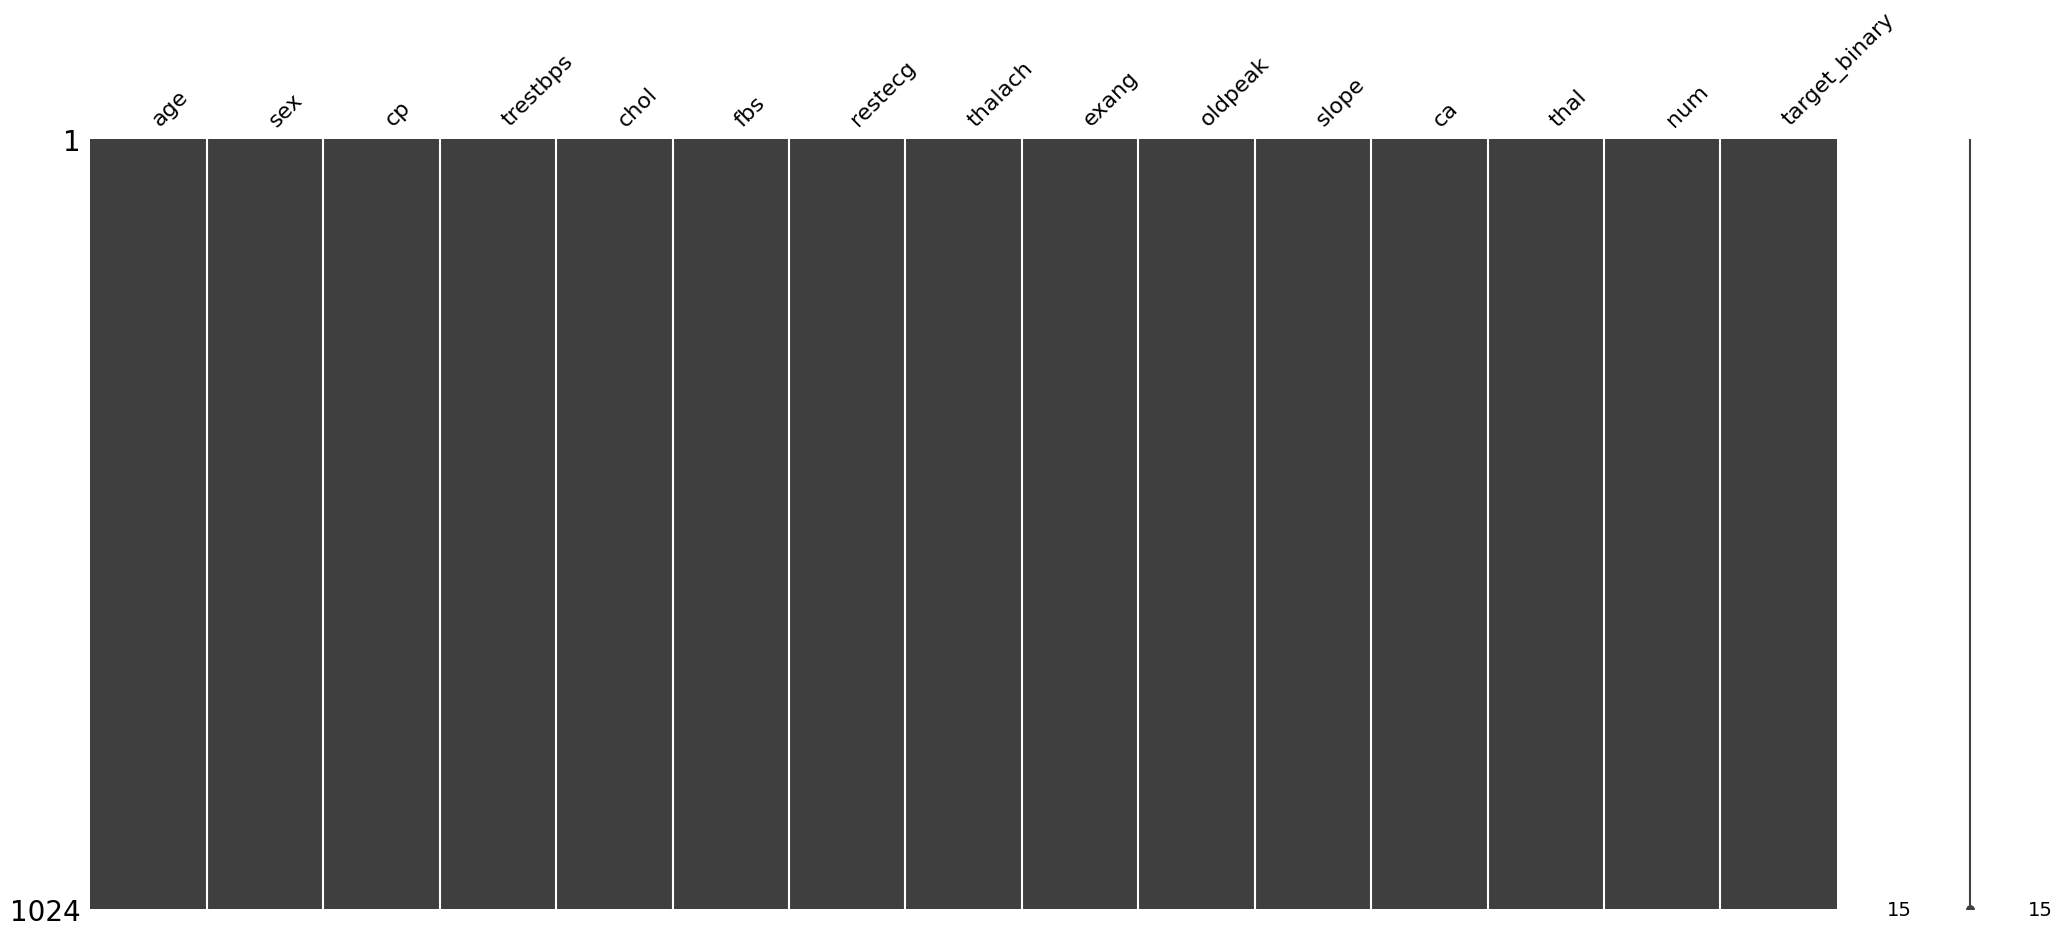

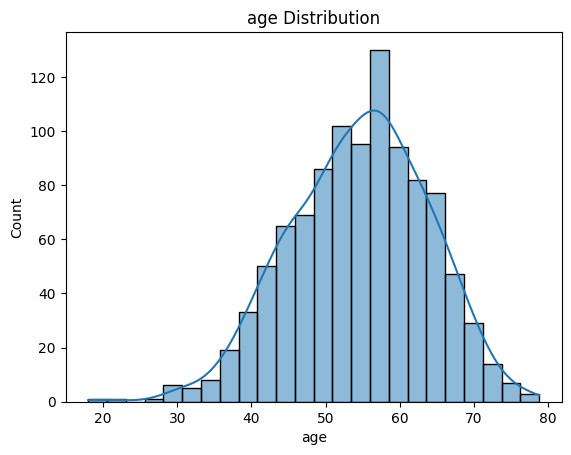

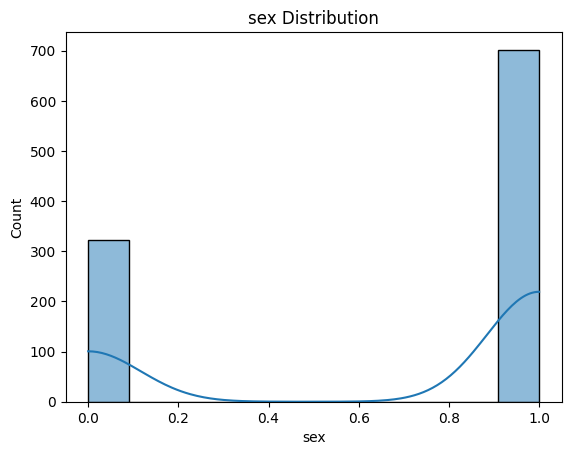

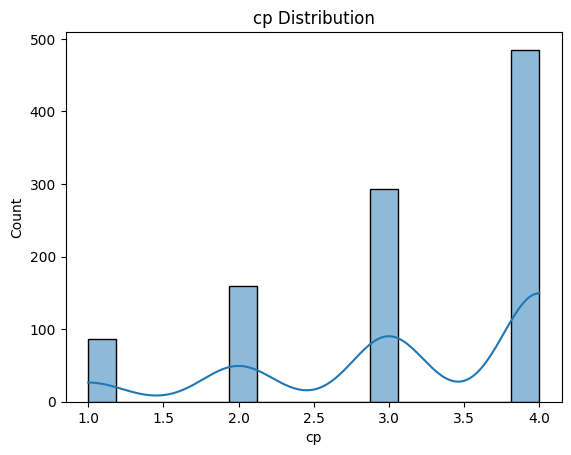

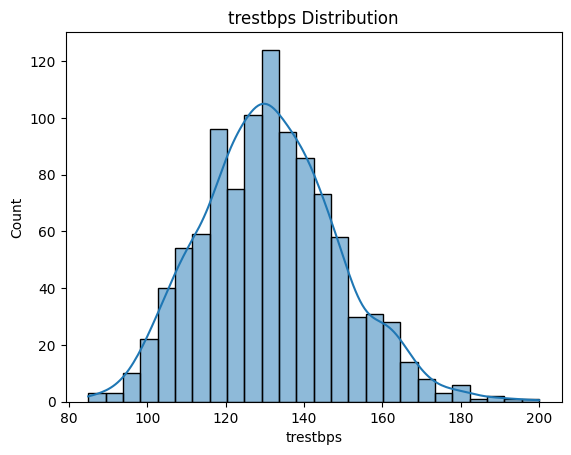

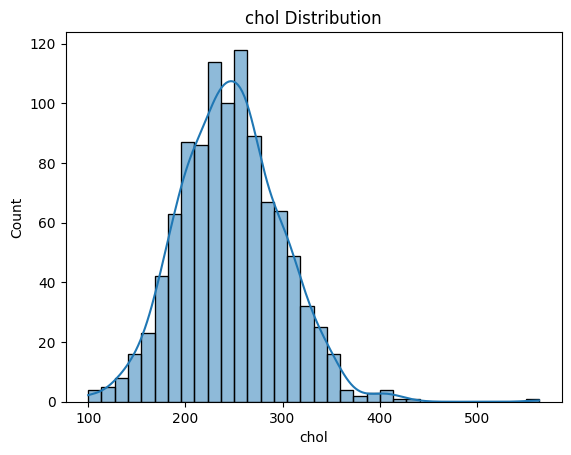

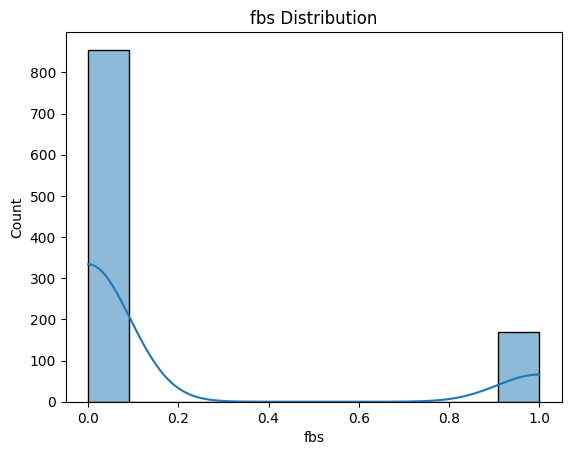

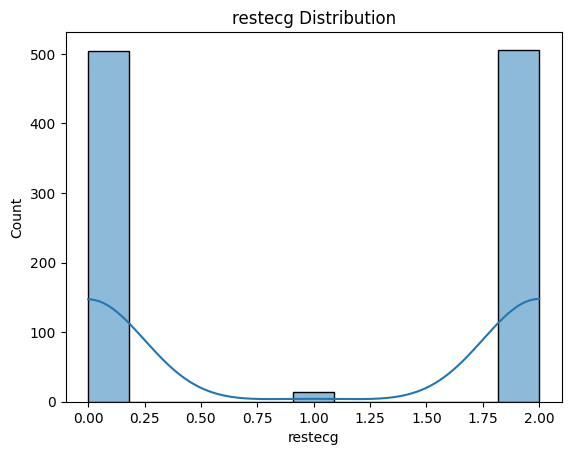

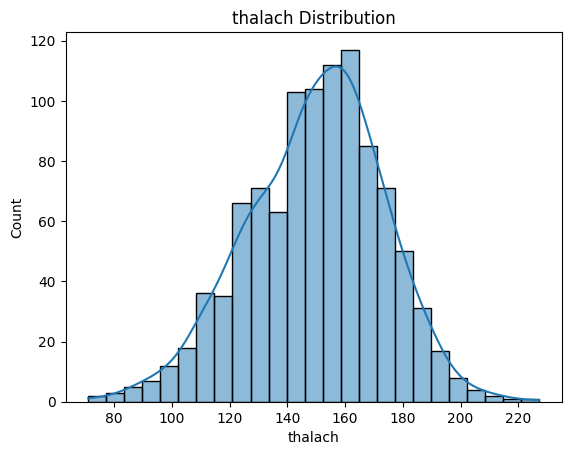

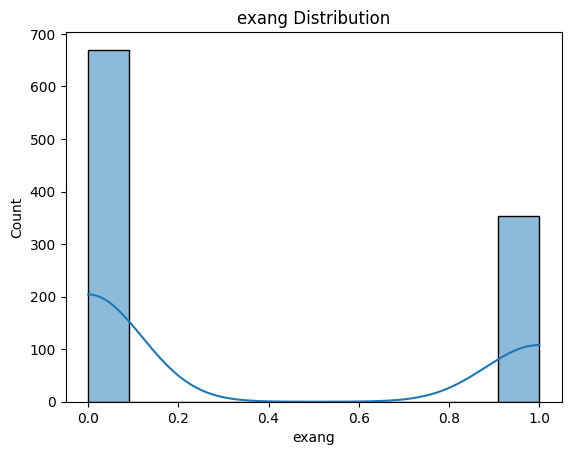

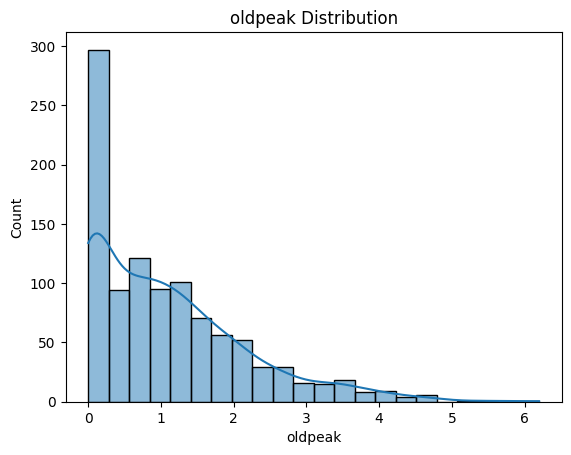

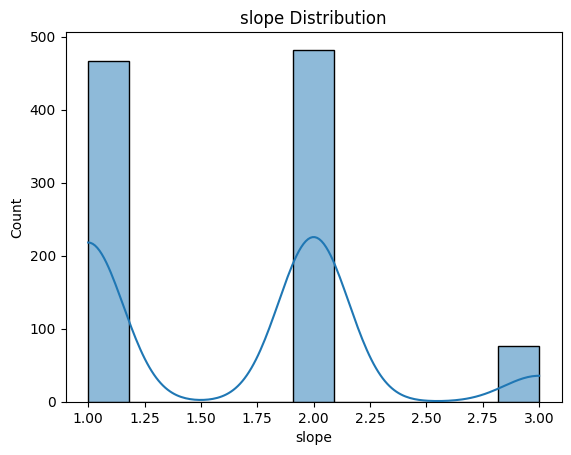

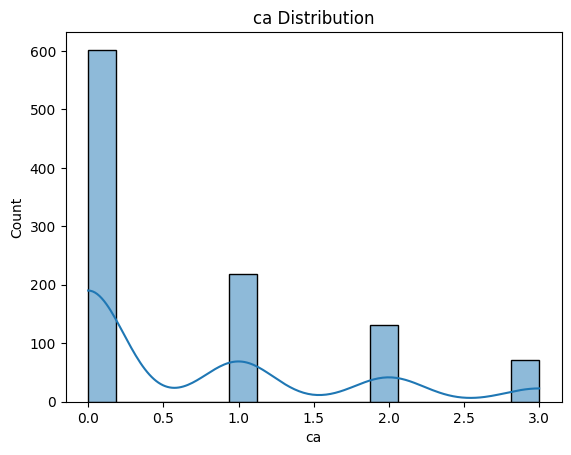

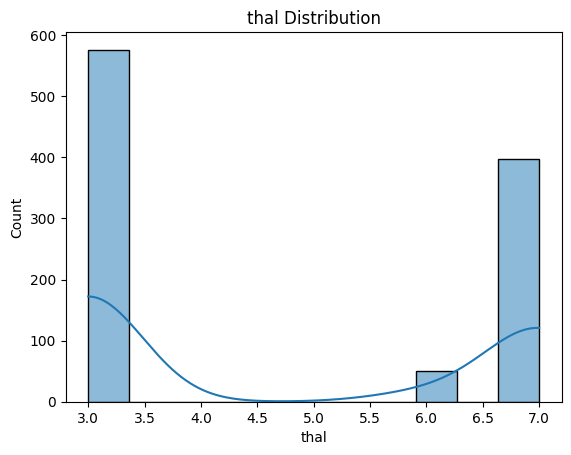

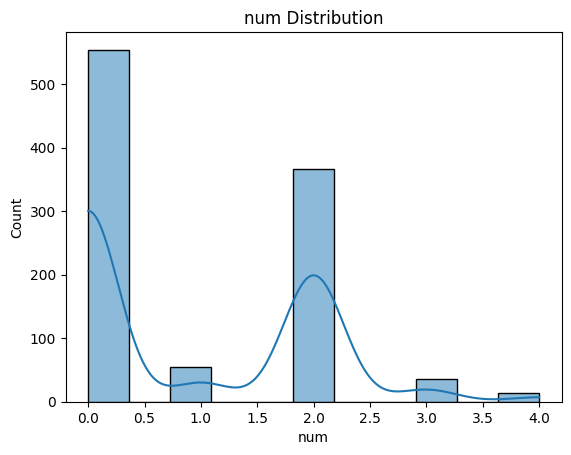


VIF REPORT
     Feature        VIF
0        age  38.231321
1        sex   3.509963
2         cp  13.549270
3   trestbps  59.046444
4       chol  25.060831
5        fbs   1.224487
6    restecg   2.135674
7    thalach  31.959003
8      exang   1.907812
9    oldpeak   2.744097
10     slope   8.753176
11        ca   1.997691
12      thal   8.949788
13       num   4.313811


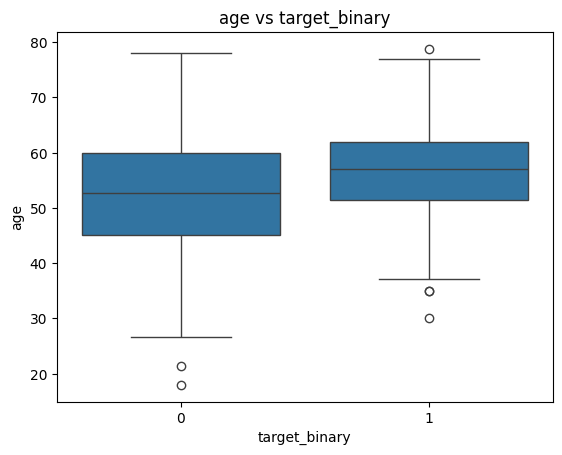

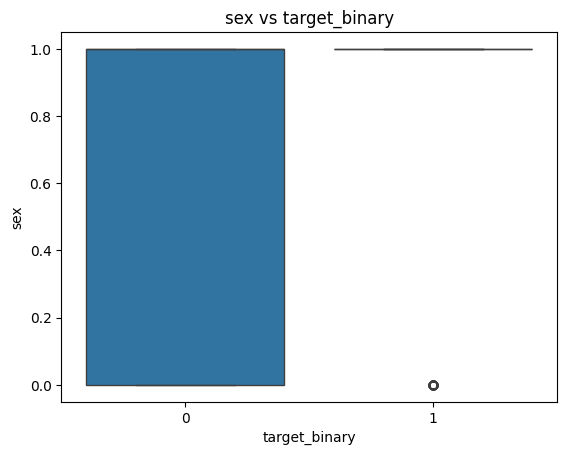

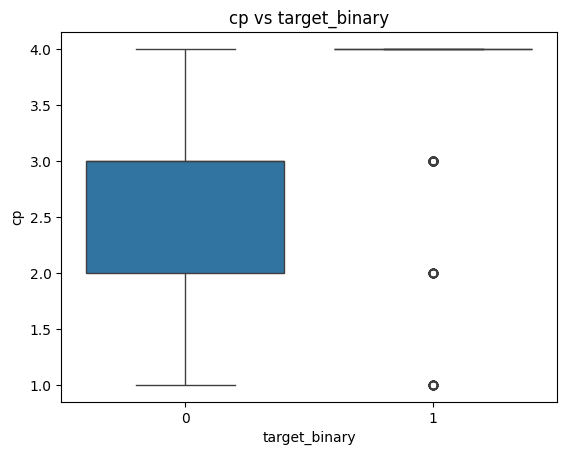

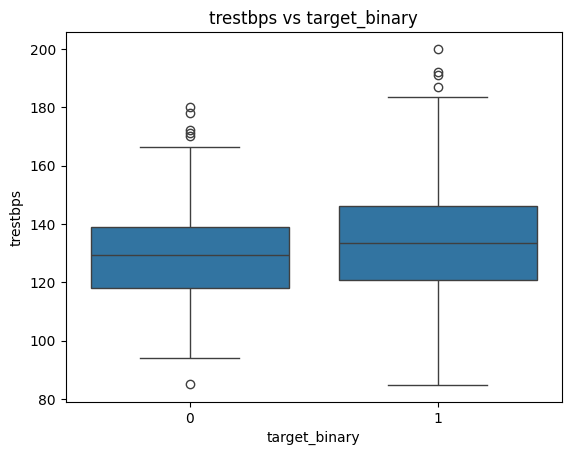

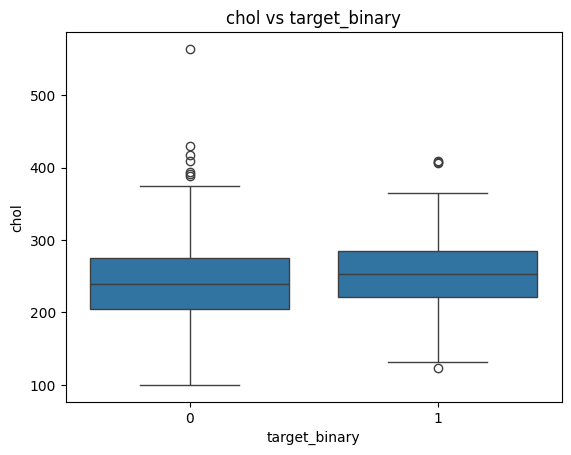

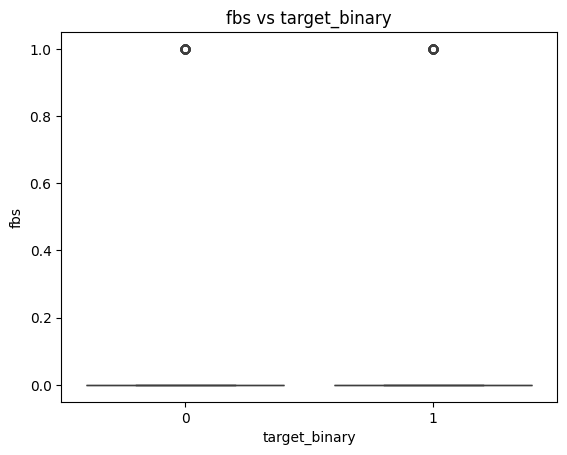

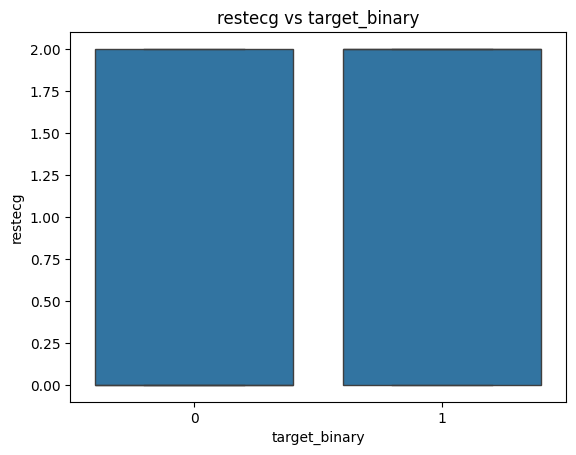

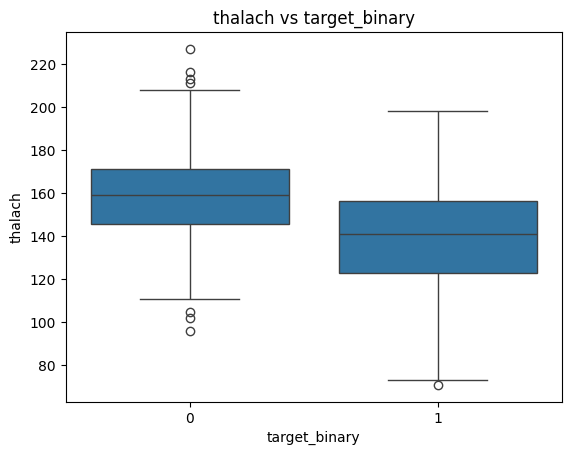

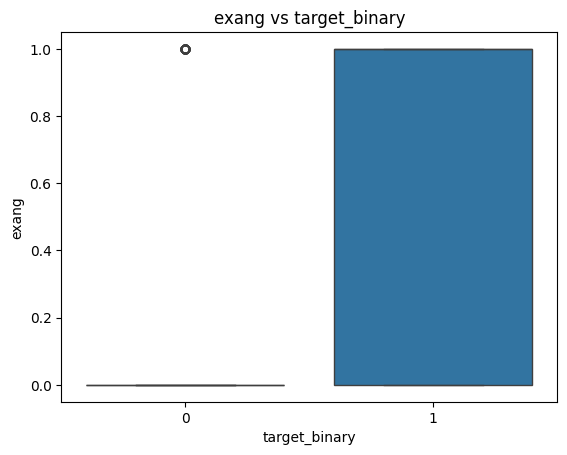

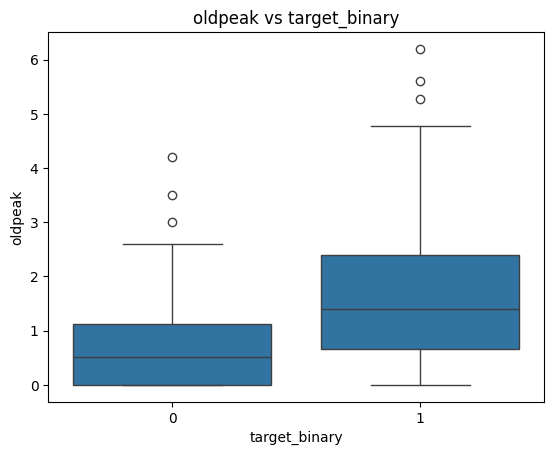

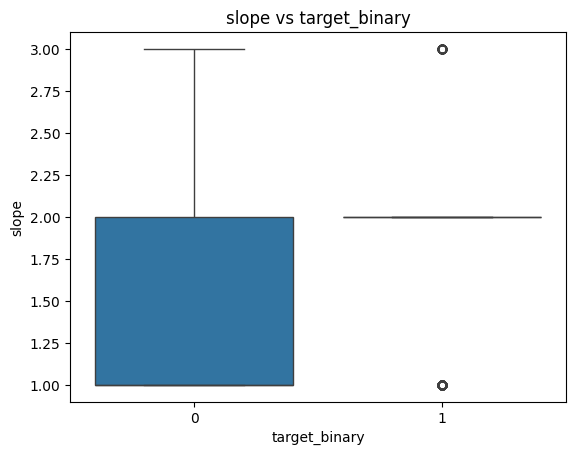

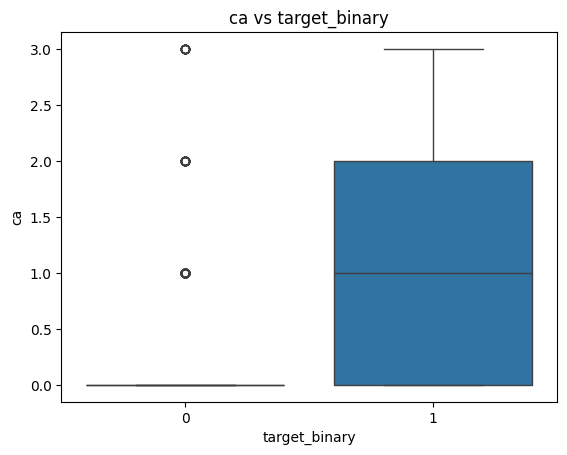

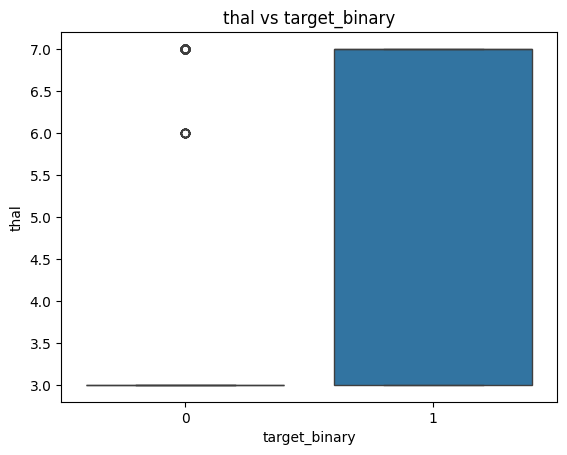

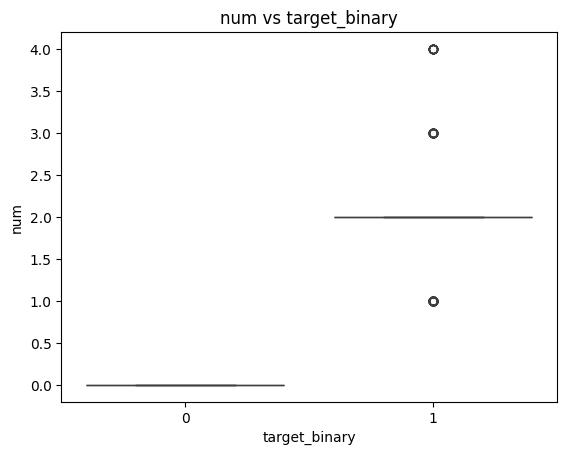

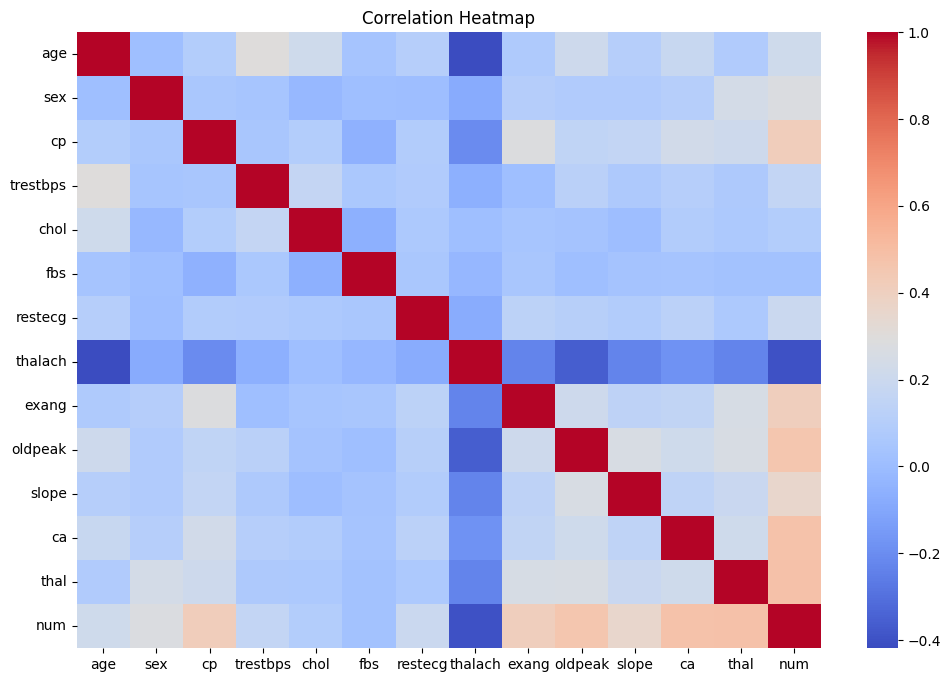


OUTLIER REPORT
age: 3 outliers
sex: 0 outliers
cp: 86 outliers
trestbps: 14 outliers
chol: 14 outliers
fbs: 169 outliers
restecg: 0 outliers
thalach: 7 outliers
exang: 0 outliers
oldpeak: 25 outliers
slope: 0 outliers
ca: 72 outliers
thal: 0 outliers
num: 0 outliers


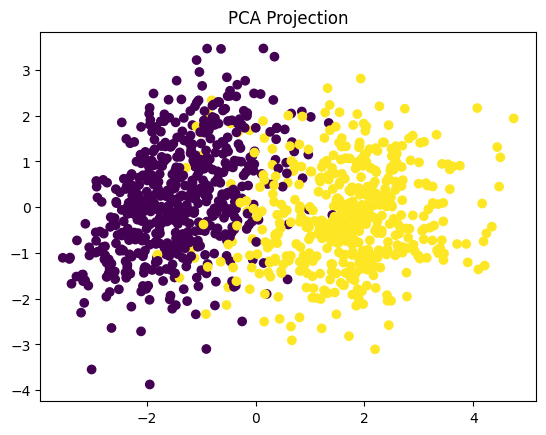


Feature Importance
     Feature  Importance
13       num    0.592399
2         cp    0.081186
11        ca    0.069374
12      thal    0.061660
9    oldpeak    0.050424
7    thalach    0.035437
8      exang    0.026572
10     slope    0.024014
0        age    0.016957
3   trestbps    0.014363
1        sex    0.011874
4       chol    0.010868
6    restecg    0.003508
5        fbs    0.001364


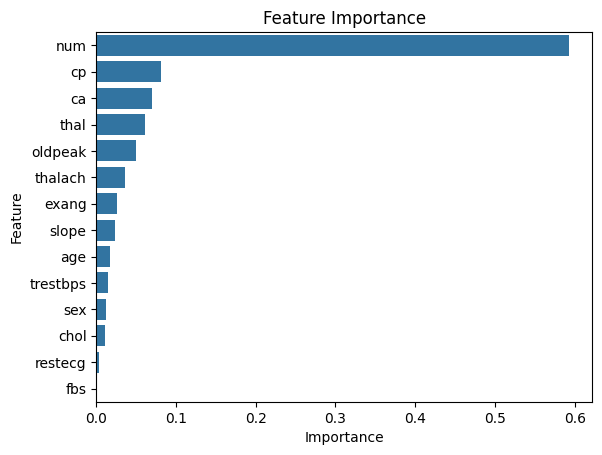


MODEL READINESS SCORECARD
✔ Missingness assessed
✔ Outliers assessed
✔ Correlation checked
✔ Multicollinearity reviewed
✔ Feature importance screened
✔ Data ready for modeling

PDF report created: reports/EDA_Report.pdf
HTML summary created


In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer
)

from reportlab.lib.pagesizes import letter
from reportlab.lib.styles import getSampleStyleSheet


#######################################
# USER INPUT
#######################################

FILE="heart_disease.csv"   # change if needed
TARGET="target_binary"     # change target variable


df=pd.read_csv(FILE)

os.makedirs("figures",exist_ok=True)
os.makedirs("reports",exist_ok=True)


#######################################
# HELPERS
#######################################

def numeric_cols():
    return df.select_dtypes(
        include=["int64","float64"]
    ).drop(
        columns=[TARGET],
        errors="ignore"
    ).columns.tolist()


def cat_cols():
    return df.select_dtypes(
        include=["object","category","bool"]
    ).drop(
        columns=[TARGET],
        errors="ignore"
    ).columns.tolist()


#######################################
# DATA QUALITY AUDIT
#######################################

quality=[]

quality.append(
f"Rows: {df.shape[0]}"
)

quality.append(
f"Columns: {df.shape[1]}"
)

quality.append(
f"Duplicate Rows: {df.duplicated().sum()}"
)

quality.append("Missing Values:")

for c,v in df.isnull().sum().items():
    quality.append(
      f"{c}: {v}"
    )

print("\nDATA QUALITY AUDIT")
for x in quality:
    print(x)

#######################################
# MISSINGNESS HEATMAP
#######################################
!pip install missingno -q

import missingno as msno

print("\nMissingness Heatmap")

msno.matrix(df)
plt.show()

#######################################
# SUMMARY STATS
#######################################

df.describe().to_csv(
 "reports/summary_stats.csv"
)



#######################################
# NUMERIC DISTRIBUTIONS
#######################################

for col in numeric_cols():

    plt.figure()
    sns.histplot(
        df[col],
        kde=True
    )
    plt.title(
      f"{col} Distribution"
    )
    plt.show()

    plt.savefig(
      f"figures/{col}_hist.png",
      bbox_inches="tight"
    )
    plt.close()

#######################################
# VIF DIAGNOSTICS
#######################################

from statsmodels.stats.outliers_influence import variance_inflation_factor

print("\nVIF REPORT")

X_vif=df[numeric_cols()].copy()

vif_df=pd.DataFrame()

vif_df["Feature"]=X_vif.columns

vif_df["VIF"]=[
variance_inflation_factor(
X_vif.values,i
)
for i in range(
X_vif.shape[1]
)
]

print(vif_df)

#######################################
# TARGET RELATIONSHIPS
#######################################

for col in numeric_cols():

    plt.figure()

    sns.boxplot(
        x=TARGET,
        y=col,
        data=df
    )

    plt.title(
      f"{col} vs {TARGET}"
    )

    plt.show()

    plt.savefig(
      f"figures/{col}_target.png",
      bbox_inches="tight"
    )

    plt.close()



#######################################
# CATEGORICAL PLOTS
#######################################

for col in cat_cols():

    plt.figure()

    sns.countplot(
      x=col,
      data=df
    )

    plt.xticks(rotation=45)

    plt.title(
      f"{col} Counts"
    )

    plt.show()

    plt.savefig(
      f"figures/{col}_count.png"
    )

    plt.close()



#######################################
# CORRELATION HEATMAP
#######################################

plt.figure(figsize=(12,8))

corr=df[numeric_cols()].corr()

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title(
 "Correlation Heatmap"
)

plt.show()

plt.savefig(
 "figures/correlation.png"
)

plt.close()



#######################################
# OUTLIER REPORT
#######################################

outliers=[]

for col in numeric_cols():

    q1=df[col].quantile(.25)
    q3=df[col].quantile(.75)

    iqr=q3-q1

    lower=q1-1.5*iqr
    upper=q3+1.5*iqr

    n=((df[col]<lower)|
       (df[col]>upper)).sum()

    outliers.append(
      f"{col}: {n} outliers"
    )

print("\nOUTLIER REPORT")
for x in outliers:
    print(x)



#######################################
# PCA
#######################################

if len(numeric_cols())>=2:

    X=df[numeric_cols()]

    X=StandardScaler().fit_transform(X)

    pcs=PCA(
      n_components=2
    ).fit_transform(X)

    plt.figure()

    plt.scatter(
      pcs[:,0],
      pcs[:,1],
      c=pd.factorize(
         df[TARGET]
      )[0]
    )

    plt.title(
      "PCA Projection"
    )

    plt.show()

    plt.savefig(
      "figures/pca.png"
    )

    plt.close()


#######################################
# FEATURE IMPORTANCE
#######################################

from sklearn.ensemble import RandomForestClassifier

print("\nFeature Importance")

X=df[numeric_cols()]
y=df[TARGET]

model=RandomForestClassifier(
n_estimators=300,
random_state=42
)

model.fit(X,y)

imp=pd.DataFrame({
"Feature":X.columns,
"Importance":model.feature_importances_
}).sort_values(
"Importance",
ascending=False
)

print(imp)

plt.figure()

sns.barplot(
data=imp,
x="Importance",
y="Feature"
)

plt.title(
"Feature Importance"
)

plt.show()

#######################################
# PDF REPORT
#######################################

print("\nMODEL READINESS SCORECARD")

print("✔ Missingness assessed")
print("✔ Outliers assessed")
print("✔ Correlation checked")
print("✔ Multicollinearity reviewed")
print("✔ Feature importance screened")
print("✔ Data ready for modeling")

pdf=SimpleDocTemplate(
 "reports/EDA_Report.pdf",
 pagesize=letter
)

styles=getSampleStyleSheet()

elements=[]

elements.append(
 Paragraph(
 "Automated Clinical EDA Report",
 styles["Title"]
 )
)

elements.append(
 Spacer(1,20)
)

elements.append(
 Paragraph(
 "Data Quality Audit",
 styles["Heading2"]
 )
)

for item in quality:
    elements.append(
      Paragraph(
      item,
      styles["BodyText"]
      )
    )


elements.append(
 Spacer(1,20)
)

elements.append(
 Paragraph(
 "Outlier Diagnostics",
 styles["Heading2"]
 )
)

for item in outliers:
    elements.append(
      Paragraph(
      item,
      styles["BodyText"]
      )
    )

elements.append(
Paragraph(
"Model Readiness: PASSED",
styles["Heading2"]
))

pdf.build(elements)

print("\nPDF report created: reports/EDA_Report.pdf")

with open(
"reports/eda_summary.html",
"w"
) as f:

    f.write(
    "<h1>Clinical EDA Summary</h1>"
    )

    for x in quality:
        f.write(
        f"<p>{x}</p>"
        )

print("HTML summary created")

In [9]:
%%writefile requirements.txt
pandas
numpy
matplotlib
seaborn
scikit-learn
statsmodels
missingno
reportlab

Overwriting requirements.txt


In [10]:
!pip freeze > requirements.txt